In [ ]:
import pandas as pd
import numpy as np
import re
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import os
import shutil

from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.preprocessing import StandardScaler

import os
import cv2
from sklearn.metrics import adjusted_rand_score

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from PIL import Image

import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from glob import glob

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.utils import shuffle

from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

import torch
from torchvision import models, transforms, datasets

from PIL import Image

import json
import urllib.request

from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv(r"/content/drive/MyDrive/OC/flipkart_com-ecommerce_sample_1050.csv", sep=",")

In [ ]:
df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa..."
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",..."
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,Key Features of SANTOSH ROYAL FASHION Cotton P...,No rating available,No rating available,SANTOSH ROYAL FASHION,"{""product_specification""=>[{""key""=>""Brand"", ""v..."
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,Key Features of Jaipur Print Cotton Floral Kin...,No rating available,No rating available,Jaipur Print,"{""product_specification""=>[{""key""=>""Machine Wa..."


In [ ]:
df['main_category'] = df['product_category_tree'].str.extract(r'(?<=\[")\s*([^>]+?)\s*(?=>>)')

le = LabelEncoder()

df["main_category_enc"] = le.fit_transform(df["main_category"])

In [ ]:
img_folder = "/content/drive/MyDrive/OC/Images"
output_folder = "/content/drive/MyDrive/OC/Images/Dataset"

for cls in df['main_category'].unique():
    os.makedirs(os.path.join(output_folder, cls), exist_ok=True)

for idx, row in tqdm(df.iterrows()):
    src = os.path.join(img_folder, row['image'])
    dst = os.path.join(output_folder, row['main_category'], row['image'])
    shutil.copy(src, dst)

1050it [13:46,  1.27it/s]


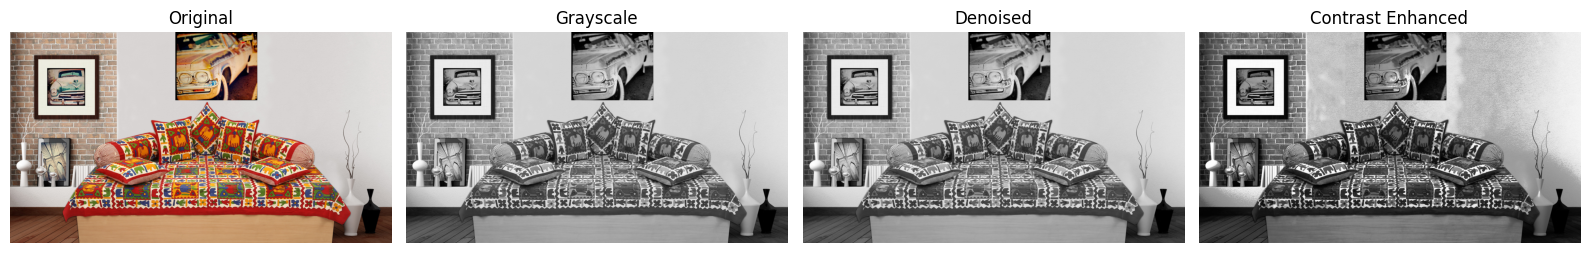

In [ ]:
image_folder = "/content/drive/MyDrive/OC"
image_name = r"/content/drive/MyDrive/OC/Images/0a8a1e9c6659361c0c2b247f8a6471d0.jpg"
img_path = os.path.join(image_folder, image_name)

img = cv2.imread(img_path)

if img is None:
    raise FileNotFoundError(f"Image not found: {img_path}")

# Convert BGR
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Noise reduction (Gaussian Blur)
denoised = cv2.GaussianBlur(gray, (5, 5), 0)

# Contrast enhancement (Histogram equalization)
contrast = cv2.equalizeHist(denoised)

fig, axes = plt.subplots(1, 4, figsize=(16, 6))
axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Grayscale")
axes[1].axis("off")

axes[2].imshow(denoised, cmap="gray")
axes[2].set_title("Denoised")
axes[2].axis("off")

axes[3].imshow(contrast, cmap="gray")
axes[3].set_title("Contrast Enhanced")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
image_folder = r"/content/drive/MyDrive/OC/Images"
output_folder = r"/content/drive/MyDrive/OC/Trans_images"

os.makedirs(output_folder, exist_ok=True)

required_cols = {"image", "product_name"}
if not required_cols.issubset(df.columns):
    raise ValueError(f"Le CSV doit contenir au moins les colonnes : {required_cols}")

failed_images = []

for _, row in tqdm(df.iterrows()):
    filename = row["image"]
    product_id = row["product_name"]

    img_path = os.path.join(image_folder, filename)
    if not os.path.exists(img_path):
        print(f"Image introuvable : {img_path}")
        failed_images.append(filename)   # <-- add missing image
        continue

    img = cv2.imread(img_path)
    if img is None:
        print(f"Impossible de lire l'image : {img_path}")
        failed_images.append(filename)
        continue

    try:
        img_resized = cv2.resize(img, (256, 256))
        gray = cv2.cvtColor(img_resized, cv2.COLOR_BGR2GRAY)
        denoised = cv2.bilateralFilter(gray, 9, 75, 75)
        equalized = cv2.equalizeHist(denoised)
        thresh = cv2.adaptiveThreshold(
            equalized, 255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY, 11, 2
        )

    except Exception as e:
        print(f"Erreur de traitement pour {filename} : {e}")
        failed_images.append(filename)
        continue

    output_filename = f"{filename}"
    output_path = os.path.join(output_folder, output_filename)

    success = cv2.imwrite(output_path, thresh)
    if not success:
        print(f"Échec de sauvegarde : {output_filename}")


1050it [07:03,  2.48it/s]


# SIFT

In [ ]:
# Dossier contenant les images
image_paths = glob("/content/drive/MyDrive/OC/Trans_images/*.jpg")

images = [cv2.imread(p, cv2.IMREAD_GRAYSCALE) for p in image_paths]

In [ ]:
len(images)

1050

In [ ]:
sift = cv2.SIFT_create()

all_descriptors = []
image_descriptors = []
failed_indices = []

for idx, img in tqdm(enumerate(images)):
    keypoints, descriptors = sift.detectAndCompute(img, None)

    # Case 1: no keypoints at all
    if len(keypoints) == 0:
        failed_indices.append(idx)
        image_descriptors.append(np.zeros((0, 128), dtype=np.float32))
        continue

    all_descriptors.append(descriptors)
    image_descriptors.append(descriptors)

print("\n","Failed indexes:", failed_indices)

1050it [00:59, 17.55it/s]


 Failed indexes: []


In [ ]:
all_descriptors = np.vstack(all_descriptors)
print("Total descriptors:", all_descriptors.shape)

Total descriptors: (861470, 128)


In [ ]:
# inertias = []
# K_values = [50, 100, 200, 300, 400, 500]

# for k in K_values:
#     print("Testing K =", k)
#     kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
#     kmeans.fit(all_descriptors)
#     inertias.append(kmeans.inertia_)

# plt.plot(K_values, inertias, marker='o')
# plt.xlabel("K (nombre de clusters)")
# plt.ylabel("Inertia")
# plt.title("Méthode du coude pour choisir K")
# plt.show()

Testing K = 50
Testing K = 100
Testing K = 200
Testing K = 250
Testing K = 300
Testing K = 350
Testing K = 400


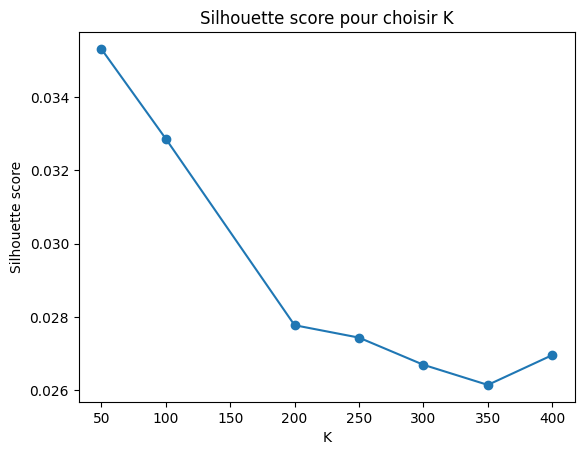

In [ ]:
# On échantillonne 10 000 descripteurs pour aller plus vite :
sample = shuffle(all_descriptors, random_state=0)[:10000]

sil_scores = []

for k in [50, 100, 200, 250, 300, 350, 400] :
    print("Testing K =", k)
    kmeans = KMeans(n_clusters=k, random_state=0, n_init='auto')
    labels = kmeans.fit_predict(sample)
    sil = silhouette_score(sample, labels)
    sil_scores.append(sil)

plt.plot([50, 100, 200, 250, 300, 350, 400], sil_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Silhouette score")
plt.title("Silhouette score pour choisir K")
plt.show()

In [ ]:
K = 300
kmeans = KMeans(n_clusters=K, random_state=0, n_init='auto')
kmeans.fit(all_descriptors)


KMeans(n_clusters=300, random_state=0)

In [ ]:
image_histograms = []

for descriptors in image_descriptors:
    if descriptors.shape[0] == 0:  # image sans descripteur
        hist = np.zeros(K)
    else:
        labels = kmeans.predict(descriptors)
        hist, _ = np.histogram(labels, bins=np.arange(K+1))
        hist = hist.astype(float) / descriptors.shape[0]  # normalisation
    image_histograms.append(hist)

image_histograms = np.array(image_histograms)
print("Shape final des features image :", image_histograms.shape)

Shape final des features image : (1050, 300)


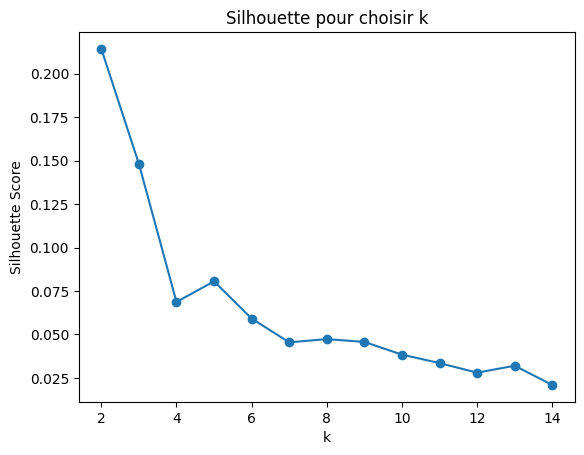

In [ ]:
silhouette_scores = []

for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(image_histograms)
    score = silhouette_score(image_histograms, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 15), silhouette_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette pour choisir k")
plt.show()

In [ ]:
num_clusters_images = 7
image_kmeans = KMeans(n_clusters=num_clusters_images, random_state=0, n_init='auto')
image_labels = image_kmeans.fit_predict(image_histograms)

print(image_labels)

[0 0 0 ... 2 5 0]


In [ ]:
df["sift_kmeans_labels"] = image_labels
df["image_descriptor"] = image_descriptors

# PCA

In [ ]:
def mean_pool(descs):
    arr = np.vstack(descs)
    return arr.mean(axis=0)

df['descriptor_global'] = df['image_descriptor'].apply(mean_pool)

X = np.vstack(df['descriptor_global'].values)
print(X.shape)

(1050, 128)


In [ ]:
X_norm = normalize(X)
pca = PCA(0.9)
X_pca = pca.fit_transform(X_norm)

In [ ]:
per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)

labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

print(f"PC1 et PC2 représentent {np.round(per_var[0] + per_var[1],2)} % de la variance expliquée donc un graph en 2D ")

PC1 et PC2 représentent 74.69999694824219 % de la variance expliquée donc un graph en 2D 


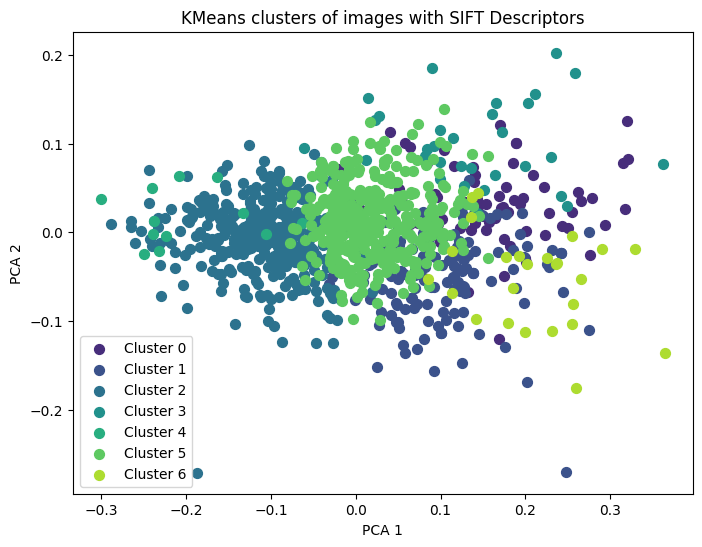

In [ ]:
plt.figure(figsize=(8, 6))
palette = sns.color_palette("viridis", n_colors=7)
for i in range(7):
    plt.scatter(
        X_pca[image_labels == i, 0],
        X_pca[image_labels == i, 1],
        s=50,
        color=palette[i],
        label=f'Cluster {i}'
    )

plt.title('KMeans clusters of images with SIFT Descriptors')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()

In [ ]:
df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications,main_category,main_category_enc,sift_kmeans_labels,image_descriptor,descriptor_global
0,55b85ea15a1536d46b7190ad6fff8ce7,2016-04-30 03:22:56 +0000,http://www.flipkart.com/elegance-polyester-mul...,Elegance Polyester Multicolor Abstract Eyelet ...,"[""Home Furnishing >> Curtains & Accessories >>...",CRNEG7BKMFFYHQ8Z,1899.0,899.0,55b85ea15a1536d46b7190ad6fff8ce7.jpg,False,Key Features of Elegance Polyester Multicolor ...,No rating available,No rating available,Elegance,"{""product_specification""=>[{""key""=>""Brand"", ""v...",Home Furnishing,4,0,"[[0.0, 0.0, 0.0, 1.0, 107.0, 10.0, 0.0, 0.0, 6...","[27.527454, 15.943428, 16.577372, 20.725458, 4..."
1,7b72c92c2f6c40268628ec5f14c6d590,2016-04-30 03:22:56 +0000,http://www.flipkart.com/sathiyas-cotton-bath-t...,Sathiyas Cotton Bath Towel,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEGFZHGBXPHZUH,600.0,449.0,7b72c92c2f6c40268628ec5f14c6d590.jpg,False,Specifications of Sathiyas Cotton Bath Towel (...,No rating available,No rating available,Sathiyas,"{""product_specification""=>[{""key""=>""Machine Wa...",Baby Care,0,0,"[[139.0, 20.0, 0.0, 1.0, 17.0, 3.0, 0.0, 0.0, ...","[32.50058, 16.643105, 11.880649, 19.06373, 49...."
2,64d5d4a258243731dc7bbb1eef49ad74,2016-04-30 03:22:56 +0000,http://www.flipkart.com/eurospa-cotton-terry-f...,Eurospa Cotton Terry Face Towel Set,"[""Baby Care >> Baby Bath & Skin >> Baby Bath T...",BTWEG6SHXTDB2A2Y,NaN,NaN,64d5d4a258243731dc7bbb1eef49ad74.jpg,False,Key Features of Eurospa Cotton Terry Face Towe...,No rating available,No rating available,Eurospa,"{""product_specification""=>[{""key""=>""Material"",...",Baby Care,0,0,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[27.699053, 18.156399, 18.411137, 24.07346, 46..."
3,d4684dcdc759dd9cdf41504698d737d8,2016-06-20 08:49:52 +0000,http://www.flipkart.com/santosh-royal-fashion-...,SANTOSH ROYAL FASHION Cotton Printed King size...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJT9UQWHDUBH4,2699.0,1299.0,d4684dcdc759dd9cdf41504698d737d8.jpg,False,Key Features of SANTOSH ROYAL FASHION Cotton P...,No rating available,No rating available,SANTOSH ROYAL FASHION,"{""product_specification""=>[{""key""=>""Brand"", ""v...",Home Furnishing,4,5,"[[0.0, 0.0, 0.0, 5.0, 17.0, 2.0, 0.0, 0.0, 14....","[25.705883, 15.002941, 18.666176, 18.547058, 4..."
4,6325b6870c54cd47be6ebfbffa620ec7,2016-06-20 08:49:52 +0000,http://www.flipkart.com/jaipur-print-cotton-fl...,Jaipur Print Cotton Floral King sized Double B...,"[""Home Furnishing >> Bed Linen >> Bedsheets >>...",BDSEJTHNGWVGWWQU,2599.0,698.0,6325b6870c54cd47be6ebfbffa620ec7.jpg,False,Key Features of Jaipur Print Cotton Floral Kin...,No rating available,No rating available,Jaipur Print,"{""product_specification""=>[{""key""=>""Machine Wa...",Home Furnishing,4,1,"[[3.0, 15.0, 24.0, 13.0, 93.0, 71.0, 1.0, 1.0,...","[23.61111, 18.335749, 11.094203, 17.743961, 47..."


In [ ]:
y_pred = df["sift_kmeans_labels"]
y_true = df["main_category_enc"]

ari_score = adjusted_rand_score(y_true, y_pred)
print("ARI:", ari_score)

ARI: 0.0011751517953724287


# Utils

In [ ]:
# TRAINING FUNCTION

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        loop = tqdm(train_loader, leave=False)
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
            loop.set_postfix(loss=running_loss/total, acc=correct/total)

        train_loss = running_loss / total
        train_acc = correct / total
        val_acc = evaluate_model(model, val_loader, device)

        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} - Val Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")

    print(f"Best validation accuracy: {best_val_acc:.4f}")

In [ ]:
# EVALUATION FUNCTION

def evaluate_model(model, data_loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

In [ ]:
# CONFUSION MATRIX

def compute_confusion_matrix(model, data_loader, device, full_dataset):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=full_dataset.classes)
    disp.plot(cmap=plt.cm.Blues)

    # Rotate x-tick labels to avoid overlapping
    plt.xticks(rotation=45, ha='right')

    plt.show()

# RESNET

## Embeddings Graph

In [ ]:
resnet = models.resnet50(pretrained=True)
model = torch.nn.Sequential(*list(resnet.children())[:-1])
model.eval()

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

image_folder = "/content/drive/MyDrive/OC/Images/"
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

resnet_embeddings = []

for img_file in tqdm(image_files):
    img_path = os.path.join(image_folder, img_file)
    img = Image.open(img_path).convert('RGB')
    img_tensor = preprocess(img).unsqueeze(0)

    with torch.no_grad():
        embedding = model(img_tensor).squeeze().numpy()

    resnet_embeddings.append(embedding)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 79.8MB/s]
 21%|██▏       | 224/1050 [01:09<03:16,  4.21it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
100%|██████████| 1050/1050 [04:59<00:00,  3.50it/s]


In [ ]:
resnet_embeddings[0].shape

(2048,)

100%|██████████| 9/9 [00:21<00:00,  2.36s/it]


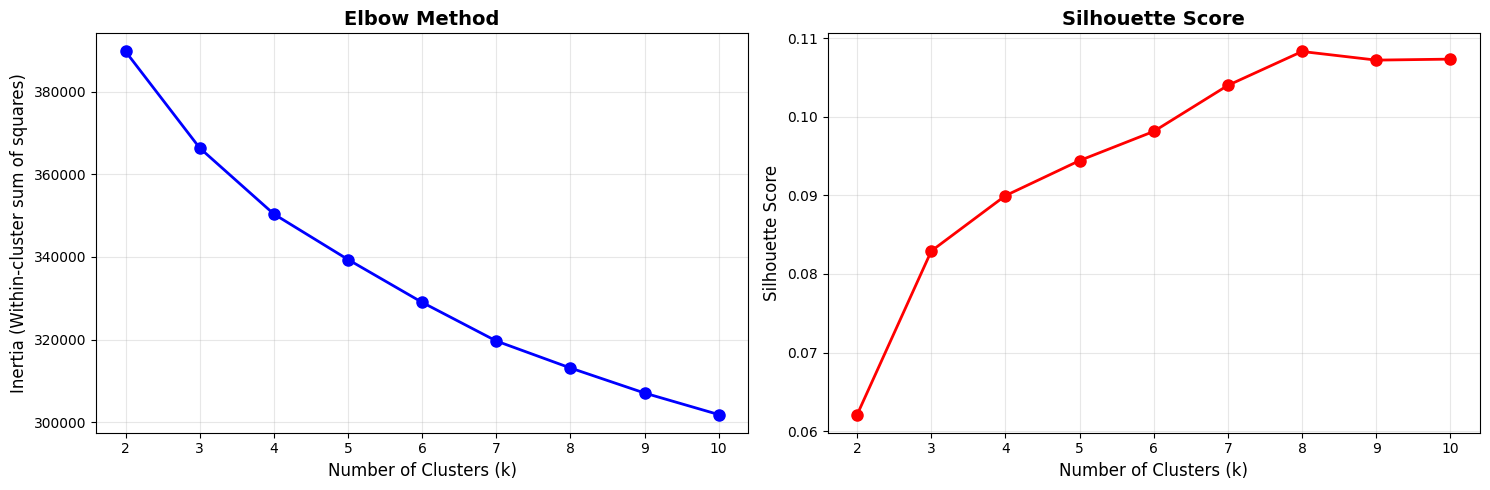

In [ ]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in tqdm(k_range):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(resnet_embeddings)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(resnet_embeddings, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Method
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_range)

# Silhouette Score
ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(k_range)

plt.tight_layout()
plt.show()

In [ ]:
n_clusters = 9

embeddings_array = np.array(resnet_embeddings)

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
resnet_kmeans_labels = kmeans.fit_predict(embeddings_array)

df["resnet_kmeans_labels"] = resnet_kmeans_labels

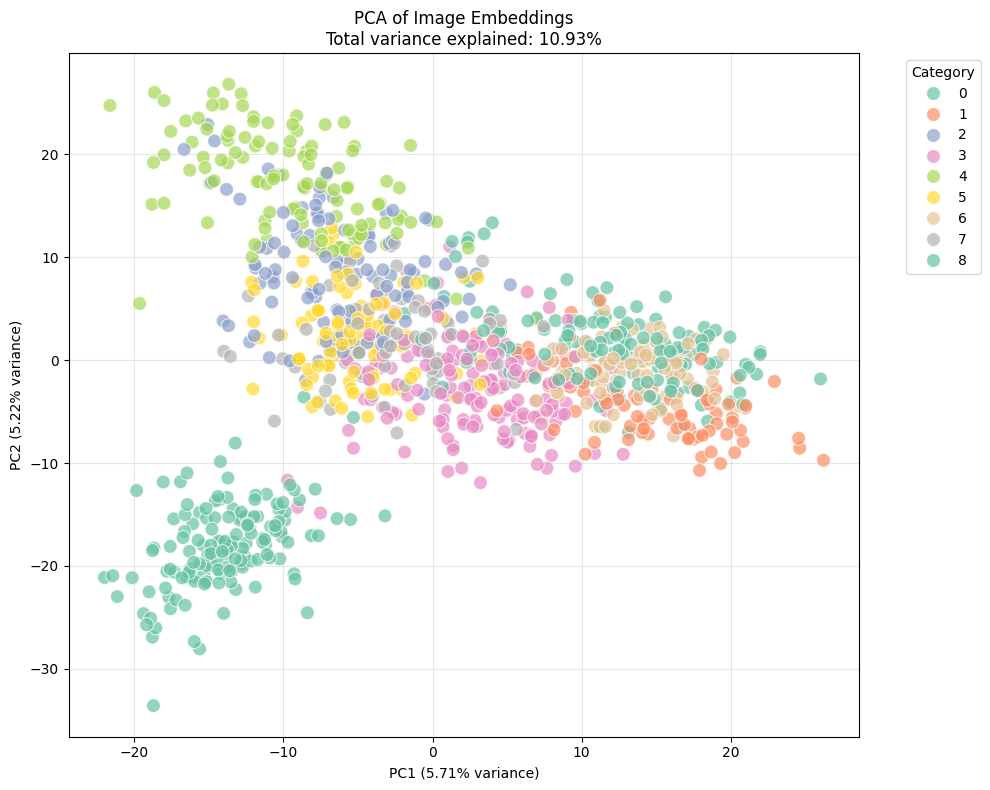

In [ ]:
df['embeddings_resnet'] = list(resnet_embeddings)

scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(np.vstack(df['embeddings_resnet'].values))

pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings_scaled)

df['pca1'] = pca_result[:, 0]
df['pca2'] = pca_result[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='resnet_kmeans_labels',
                s=100, alpha=0.7, palette='Set2')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'PCA of Image Embeddings\nTotal variance explained: {sum(pca.explained_variance_ratio_):.2%}')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Bottleneck time

In [ ]:
# PARAMETERS

num_classes = 7
batch_size = 32
num_epochs = 5
learning_rate_head = 1e-3
learning_rate_backbone = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# DATASET & TRANSFORMATIONS

data_dir = "/content/drive/MyDrive/OC/Images/Dataset"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Split into train, val, test (70%, 15%, 15%)
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
# MODEL

resnet = models.resnet50(weights='DEFAULT')

# Freeze backbone
for param in resnet.parameters():
    param.requires_grad = False

# Replace classifier (fc)
in_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Linear(128, num_classes)
)

resnet = resnet.to(device)

# LOSS & OPTIMIZER

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, resnet.parameters()), lr=learning_rate_head)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 148MB/s]


In [ ]:
# TRAIN
train_model(resnet, train_loader, val_loader, criterion, optimizer, num_epochs, device)

  0%|          | 0/23 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch [1/5]:  70%|██████▉   | 16/23 [02:53<01:11, 10.20s/it, acc=0.6, loss=1.46]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [1/5] - Train Loss: 1.2098 - Train Acc: 0.6680 - Val Acc: 0.8471


Epoch [2/5]:  22%|██▏       | 5/23 [00:54<03:07, 10.41s/it, acc=0.869, loss=0.468]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [2/5] - Train Loss: 0.5161 - Train Acc: 0.8354 - Val Acc: 0.8344


Epoch [3/5]:  22%|██▏       | 5/23 [00:56<03:16, 10.91s/it, acc=0.863, loss=0.388]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [3/5] - Train Loss: 0.3567 - Train Acc: 0.8871 - Val Acc: 0.8153


Epoch [4/5]:  52%|█████▏    | 12/23 [02:07<01:52, 10.27s/it, acc=0.958, loss=0.172]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [4/5] - Train Loss: 0.2064 - Train Acc: 0.9483 - Val Acc: 0.8408


Epoch [5/5]:  39%|███▉      | 9/23 [01:38<02:26, 10.46s/it, acc=0.976, loss=0.0928]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [5/5] - Train Loss: 0.1316 - Train Acc: 0.9592 - Val Acc: 0.8535
Best validation accuracy: 0.8535


In [ ]:
# EVALUATION

resnet.load_state_dict(torch.load("best_model.pth"))

val_accuracy = evaluate_model(resnet, val_loader, device)
test_accuracy = evaluate_model(resnet, test_loader, device)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Validation Accuracy: 0.8535
Test Accuracy: 0.8228


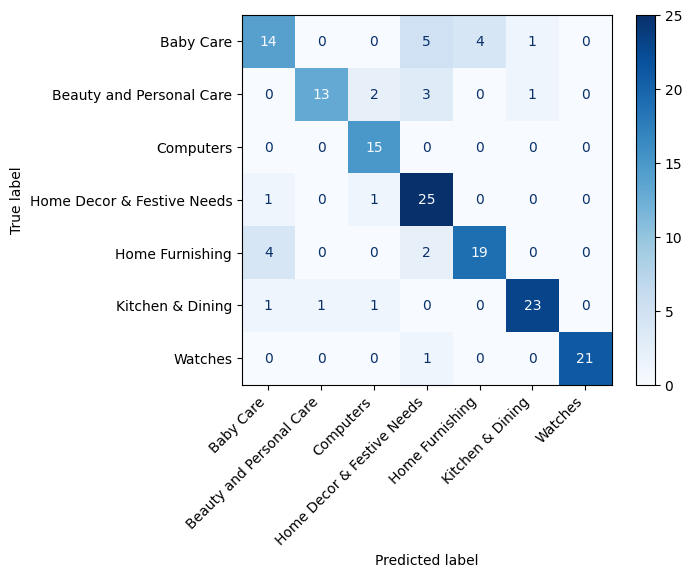

In [ ]:
# CONFUSION MATRIX ON TEST SET

compute_confusion_matrix(resnet, test_loader, device, full_dataset)

# EfficientNet

## Embeddings Graph

In [ ]:
efficientnet = models.efficientnet_b0(pretrained=True)

model = torch.nn.Sequential(
    efficientnet.features,
    efficientnet.avgpool,
    torch.nn.Flatten()
)
model.eval()

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

image_folder = "/content/drive/MyDrive/OC/Images/"
image_files = [f for f in os.listdir(image_folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

efficientnet_embeddings = []

for img_file in tqdm(image_files):
    img_path = os.path.join(image_folder, img_file)
    img = Image.open(img_path).convert('RGB')
    img_tensor = preprocess(img).unsqueeze(0)

    with torch.no_grad():
        embedding = model(img_tensor).squeeze().numpy()

    efficientnet_embeddings.append(embedding)

print(f"Extracted {len(efficientnet_embeddings)} embeddings")
print(f"Each embedding shape: {efficientnet_embeddings[0].shape}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 133MB/s]
 21%|██        | 223/1050 [00:29<01:11, 11.53it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
100%|██████████| 1050/1050 [01:52<00:00,  9.36it/s]

Extracted 1050 embeddings
Each embedding shape: (1280,)


100%|██████████| 9/9 [00:13<00:00,  1.52s/it]


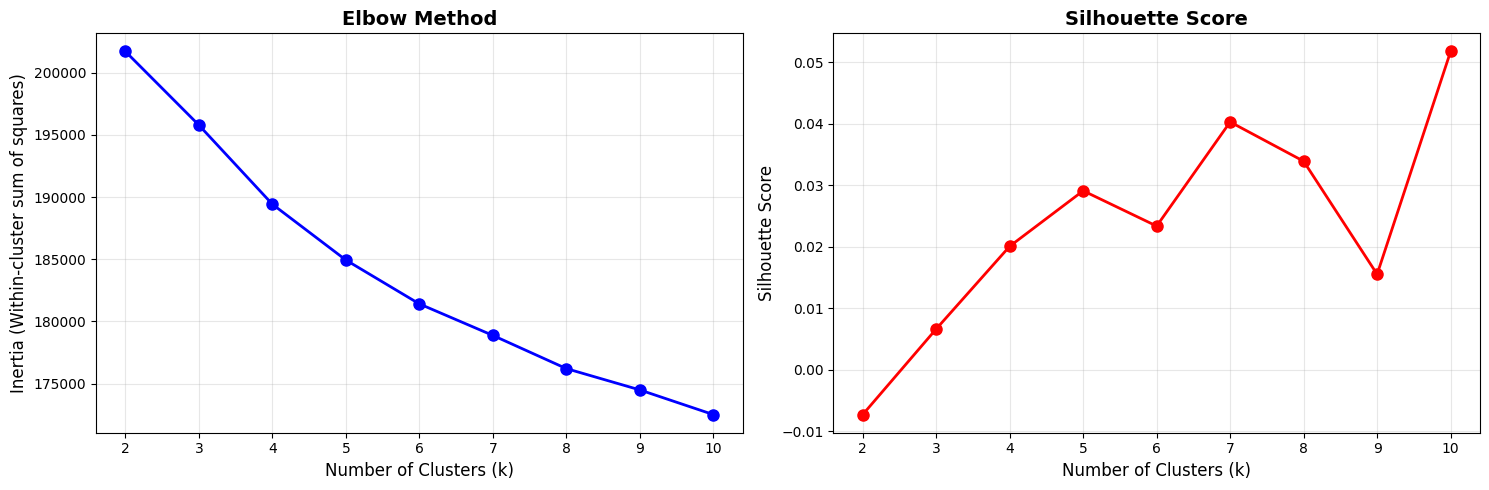

In [ ]:
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in tqdm(k_range):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(efficientnet_embeddings)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(efficientnet_embeddings, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Method
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia (Within-cluster sum of squares)', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_range)

# Silhouette Score
ax2.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(k_range)

plt.tight_layout()
plt.show()

In [ ]:
n_clusters = 8

embeddings_array = np.array(efficientnet_embeddings)

kmeans = KMeans(n_clusters=n_clusters, random_state=42)
efficientnet_kmeans_labels = kmeans.fit_predict(embeddings_array)

df["efficientnet_kmeans_labels"] = efficientnet_kmeans_labels

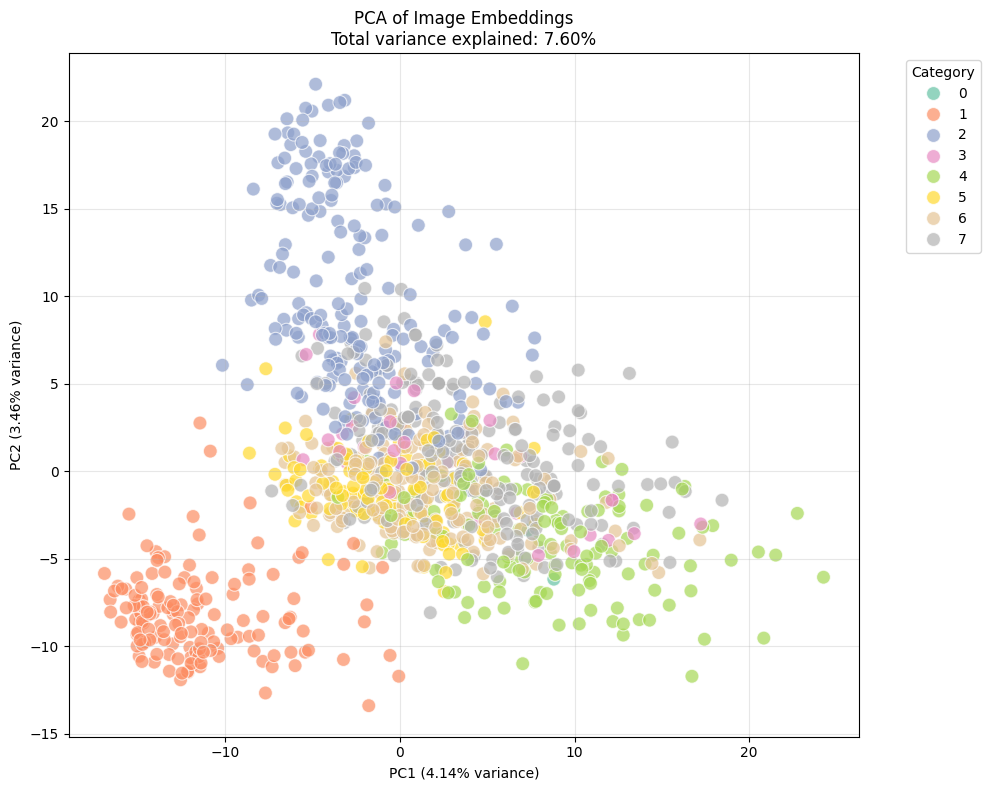

In [ ]:
df['embeddings_efficientnet'] = list(efficientnet_embeddings)

scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(np.vstack(df['embeddings_efficientnet'].values))

pca = PCA(n_components=2)
pca_result = pca.fit_transform(embeddings_scaled)

df['pca1'] = pca_result[:, 0]
df['pca2'] = pca_result[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='efficientnet_kmeans_labels',
                s=100, alpha=0.7, palette='Set2')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title(f'PCA of Image Embeddings\nTotal variance explained: {sum(pca.explained_variance_ratio_):.2%}')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Bottleneck Time

In [ ]:
# PARAMETERS

num_classes = 7
batch_size = 32
num_epochs = 5
learning_rate_head = 1e-3
learning_rate_backbone = 1e-4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# DATASET & TRANSFORMATIONS

data_dir = "/content/drive/MyDrive/OC/Images/Dataset"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# Split into train, val, test (70%, 15%, 15%)
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
# MODEL

efficientnet = models.efficientnet_b0(weights='DEFAULT')

# Freeze backbone
for param in efficientnet.parameters():
    param.requires_grad = False

# 3-layer classifier
in_features = efficientnet.classifier[1].in_features
efficientnet.classifier = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Linear(128, num_classes)
)

efficientnet = efficientnet.to(device)

# LOSS & OPTIMIZER

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, efficientnet.parameters()), lr=learning_rate_head)

In [ ]:
# TRAIN
train_model(efficientnet, train_loader, val_loader, criterion, optimizer, num_epochs, device)

  0%|          | 0/23 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch [1/5]:   4%|▍         | 1/23 [00:07<02:50,  7.74s/it, acc=0.188, loss=1.94]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [1/5] - Train Loss: 1.4694 - Train Acc: 0.5388 - Val Acc: 0.8025


  0%|          | 0/23 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [2/5] - Train Loss: 0.6953 - Train Acc: 0.7796 - Val Acc: 0.8344


Epoch [3/5]:  48%|████▊     | 11/23 [00:48<00:50,  4.22s/it, acc=0.852, loss=0.48]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [3/5] - Train Loss: 0.4203 - Train Acc: 0.8653 - Val Acc: 0.8280


  0%|          | 0/23 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [4/5] - Train Loss: 0.3050 - Train Acc: 0.8966 - Val Acc: 0.8408


  0%|          | 0/23 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [5/5] - Train Loss: 0.1828 - Train Acc: 0.9456 - Val Acc: 0.8089
Best validation accuracy: 0.8408


In [ ]:
# EVALUATION

efficientnet.load_state_dict(torch.load("best_model.pth"))

val_accuracy = evaluate_model(efficientnet, val_loader, device)
test_accuracy = evaluate_model(efficientnet, test_loader, device)
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Validation Accuracy: 0.8408
Test Accuracy: 0.7468


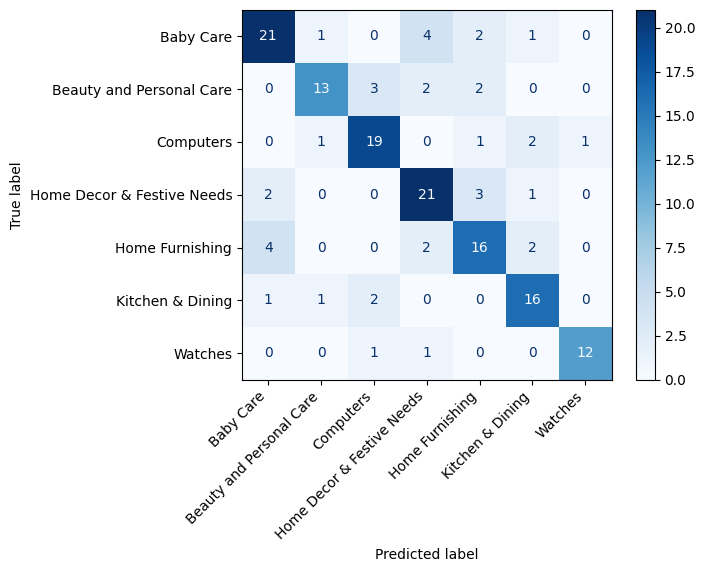

In [ ]:
# CONFUSION MATRIX ON TEST SET

compute_confusion_matrix(efficientnet, test_loader, device, full_dataset)

# Data augmentation

In [ ]:
num_classes = 7
batch_size = 32
num_epochs = 5
learning_rate_head = 1e-3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
data_dir = "/content/drive/MyDrive/OC/Images/Dataset"

# TRAIN: with augmentation
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

# VAL / TEST: no augmentation
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

In [ ]:
full_dataset = datasets.ImageFolder(root=data_dir)
total_size = len(full_dataset)

indices = np.random.permutation(total_size)
train_end = int(0.7 * total_size)
val_end = int(0.85 * total_size)

train_indices = indices[:train_end]
val_indices = indices[train_end:val_end]
test_indices = indices[val_end:]

In [ ]:
train_dataset = Subset(
    datasets.ImageFolder(data_dir, transform=train_transform),
    train_indices)

val_dataset = Subset(
    datasets.ImageFolder(data_dir, transform=eval_transform),
    val_indices)

test_dataset = Subset(
    datasets.ImageFolder(data_dir, transform=eval_transform),
    test_indices)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                         num_workers=2, pin_memory=True)


In [ ]:
# MODEL
resnet = models.resnet50(weights='DEFAULT')

# Freeze backbone
for param in resnet.parameters():
    param.requires_grad = False

# Replace classifier (fc)
in_features = resnet.fc.in_features
resnet.fc = nn.Sequential(
    nn.Linear(in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Linear(128, num_classes)
)

resnet = resnet.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()),
    lr=learning_rate_head)

In [ ]:
train_model(resnet, train_loader, val_loader,
            criterion, optimizer, num_epochs, device)

  0%|          | 0/23 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch [1/5]:   4%|▍         | 1/23 [00:15<05:38, 15.39s/it, acc=0.156, loss=1.95]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [1/5] - Train Loss: 1.3093 - Train Acc: 0.5741 - Val Acc: 0.7834


Epoch [2/5]:  70%|██████▉   | 16/23 [02:45<01:10, 10.12s/it, acc=0.783, loss=0.64]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [2/5] - Train Loss: 0.6346 - Train Acc: 0.7864 - Val Acc: 0.8025


Epoch [3/5]:  39%|███▉      | 9/23 [01:43<02:38, 11.31s/it, acc=0.854, loss=0.464]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [3/5] - Train Loss: 0.5052 - Train Acc: 0.8367 - Val Acc: 0.8153


Epoch [4/5]:  13%|█▎        | 3/23 [00:35<03:45, 11.30s/it, acc=0.833, loss=0.437]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [4/5] - Train Loss: 0.3420 - Train Acc: 0.8871 - Val Acc: 0.7962


Epoch [5/5]:  70%|██████▉   | 16/23 [02:51<01:13, 10.50s/it, acc=0.928, loss=0.253]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (93680328 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Epoch [5/5] - Train Loss: 0.2664 - Train Acc: 0.9129 - Val Acc: 0.8662
Best validation accuracy: 0.8662


In [ ]:
resnet.load_state_dict(torch.load("best_model.pth"))

val_accuracy = evaluate_model(resnet, val_loader, device)
test_accuracy = evaluate_model(resnet, test_loader, device)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Validation Accuracy: 0.8662
Test Accuracy: 0.8924


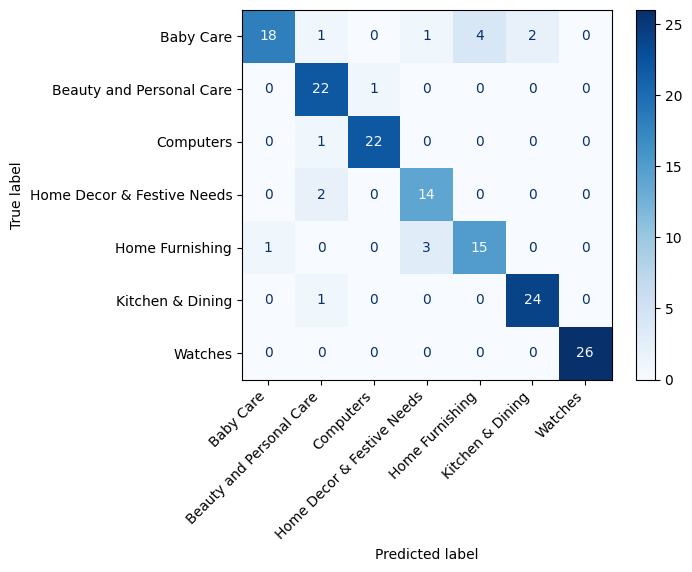

In [ ]:
compute_confusion_matrix(resnet, test_loader, device, full_dataset)